## 0. Setup & Data Cleaning

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', None)

# Load raw data (Superstore CSVs are typically Latin-1 encoded, not UTF-8)
df = pd.read_csv('superstoree.csv', encoding='latin1')
print("Raw shape:", df.shape)
df.head(3)


Raw shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [12]:
# --- Cleaning ---
# 1. Standardize column names (snake_case, no spaces/dashes)
df.columns = (df.columns
              .str.strip()
              .str.replace(' ', '_')
              .str.replace('-', '_')
              .str.lower())

# 2. Parse dates
df['order_date'] = pd.to_datetime(df['order_date'], format='%m/%d/%Y', errors='coerce')
df['ship_date']  = pd.to_datetime(df['ship_date'],  format='%m/%d/%Y', errors='coerce')

# 3. Drop exact duplicate rows and rows missing a valid order date
before = len(df)
df = df.drop_duplicates()
df = df.dropna(subset=['order_date'])
print(f"Dropped {before - len(df)} duplicate/invalid rows")

# 4. Derived time columns used throughout the notebook
df['order_month'] = df['order_date'].dt.to_period('M').dt.to_timestamp()
df['month_label'] = df['order_date'].dt.strftime('%b %Y')

# 5. Sanity checks
print("Nulls per column:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("Final shape:", df.shape)

# Save the cleaned dataset for submission
df.to_csv('superstore_cleaned.csv', index=False)
print("Saved superstore_cleaned.csv")


Dropped 0 duplicate/invalid rows
Nulls per column:
 Series([], dtype: int64)
Final shape: (9994, 23)
Saved superstore_cleaned.csv


## Task 1 — Same Data, Multiple Chart Types


In [13]:
monthly_sales = df.groupby('order_month')['sales'].sum().sort_index()
monthly_sales.index = monthly_sales.index.strftime('%b %Y')
monthly_sales.head()


,sales
order_month,
Jan 2014,14236.895
Feb 2014,4519.892
Mar 2014,55691.009
Apr 2014,28295.345
May 2014,23648.287


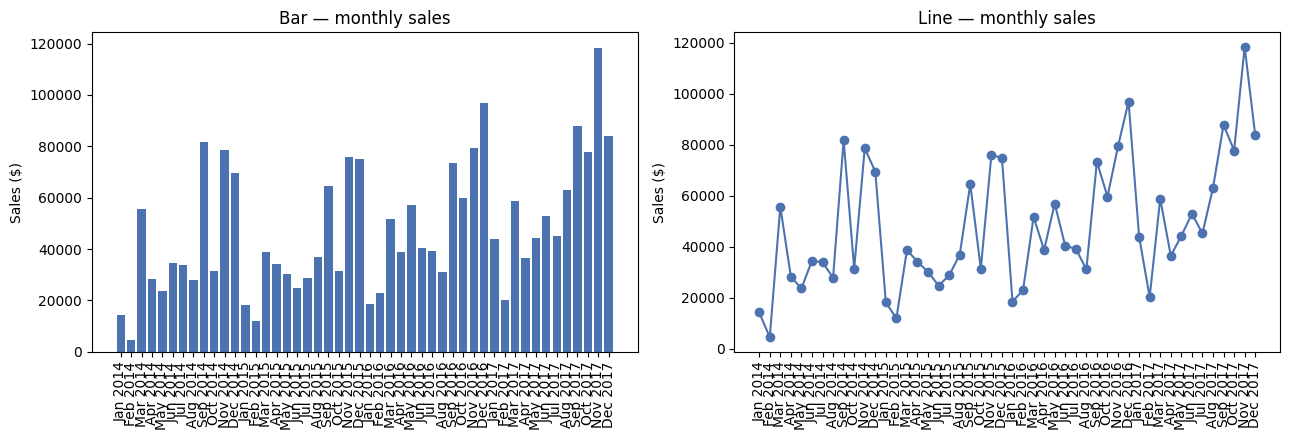

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(monthly_sales.index, monthly_sales.values, color='#4C72B0')
axes[0].set_title('Bar — monthly sales')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=90)

axes[1].plot(monthly_sales.index, monthly_sales.values, marker='o', color='#4C72B0')
axes[1].set_title('Line — monthly sales')
axes[1].set_ylabel('Sales ($)')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


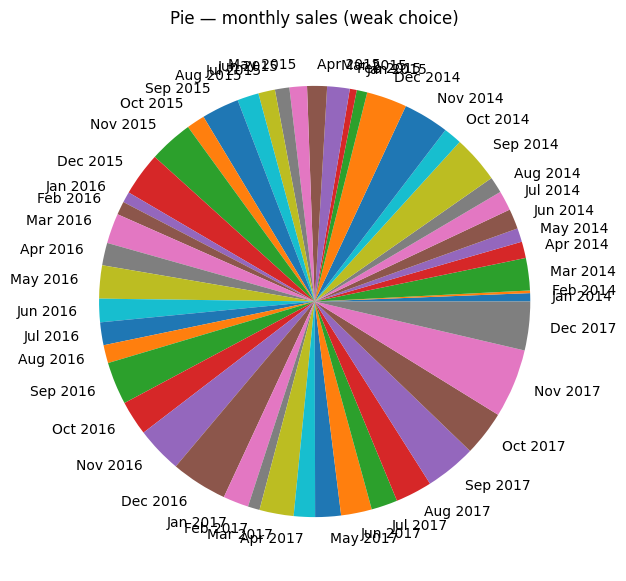

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(monthly_sales.values, labels=monthly_sales.index, autopct=None)
ax.set_title('Pie — monthly sales (weak choice)')
plt.show()


## Task 2 — Effectiveness & Appropriateness


### 2a. "Compare total sales across the top 5 sub-categories." → Bar chart

In [16]:
top5_subcat = (df.groupby('sub_category')['sales'].sum()
                 .sort_values(ascending=False).head(5))
top5_subcat


,sales
sub_category,
Phones,330007.054
Chairs,328449.103
Storage,223843.608
Tables,206965.532
Binders,203412.733


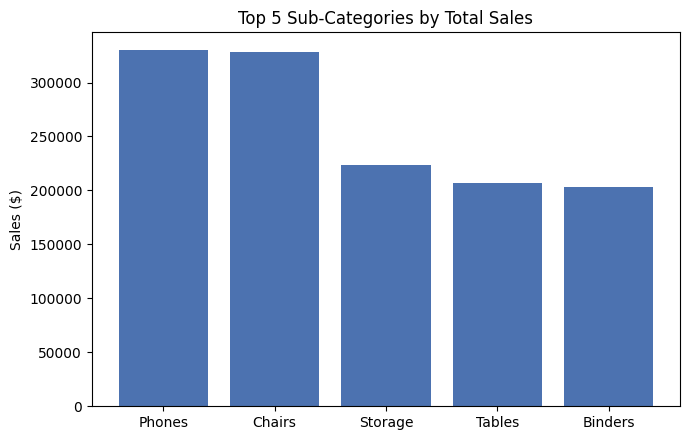

In [17]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(top5_subcat.index, top5_subcat.values, color='#4C72B0')
ax.set_title('Top 5 Sub-Categories by Total Sales')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()


### 2b. "Show the revenue trend over time.

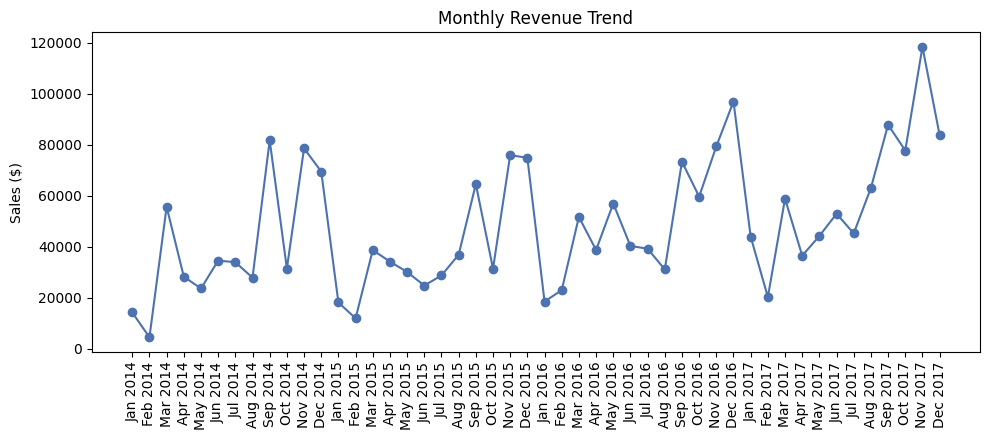

In [39]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_sales.index, monthly_sales.values, marker='o', color='#4C72B0')
ax.set_title('Monthly Revenue Trend')
ax.set_ylabel('Sales ($)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


### 2c. "Show the distribution of order-line sales values.(how often sale values are occuring

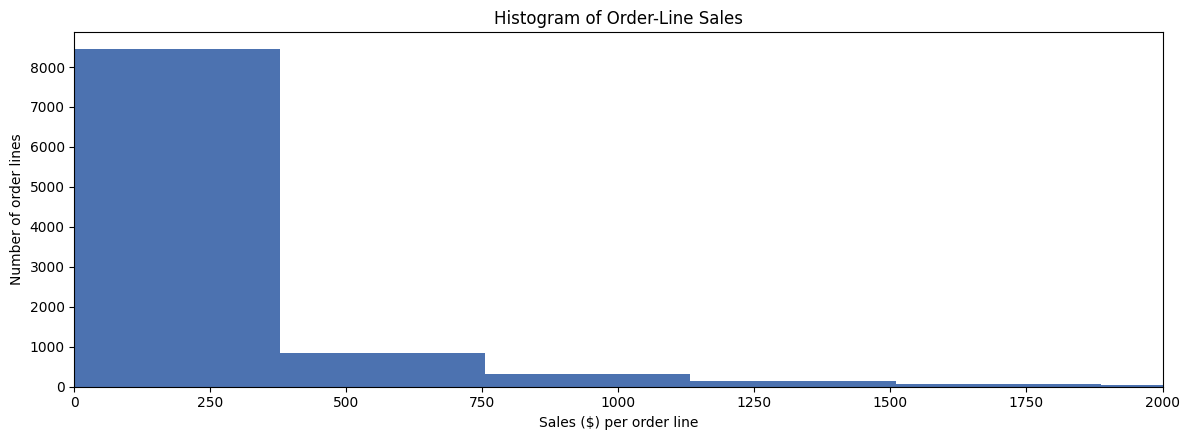

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: sales, dtype: float64


In [40]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.hist(df['sales'], bins=60, color='#4C72B0')
ax.set_title('Histogram of Order-Line Sales')
ax.set_xlabel('Sales ($) per order line')
ax.set_ylabel('Number of order lines')
ax.set_xlim(0, 2000)
plt.tight_layout()
plt.show()

print(df['sales'].describe())

### 2d. "Show the relationship between discount level and profit

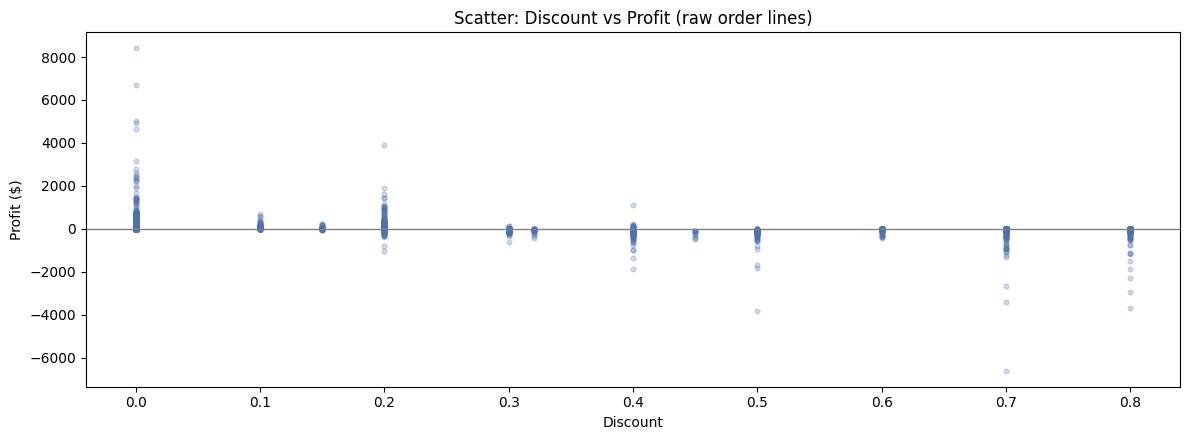

In [26]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.scatter(df['discount'], df['profit'], alpha=0.25, s=12, color='#4C72B0')
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('Scatter: Discount vs Profit (raw order lines)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.show()

## Task 3 — Color Selection

### 3a. Region sales — categorical palette (fixed, distinguishable hues)

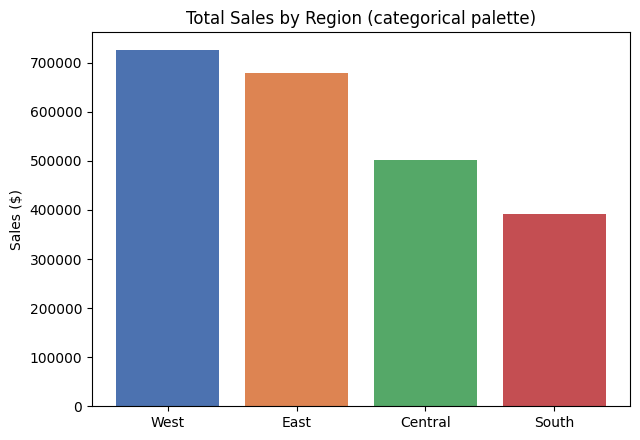

In [27]:
region_sales = df.groupby('region')['sales'].sum().sort_values(ascending=False)
cat_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(region_sales.index, region_sales.values, color=cat_palette[:len(region_sales)])
ax.set_title('Total Sales by Region (categorical palette)')
ax.set_ylabel('Sales ($)')
plt.tight_layout()
plt.show()


### 3b. Region × Category — heatmap with a sequential palette

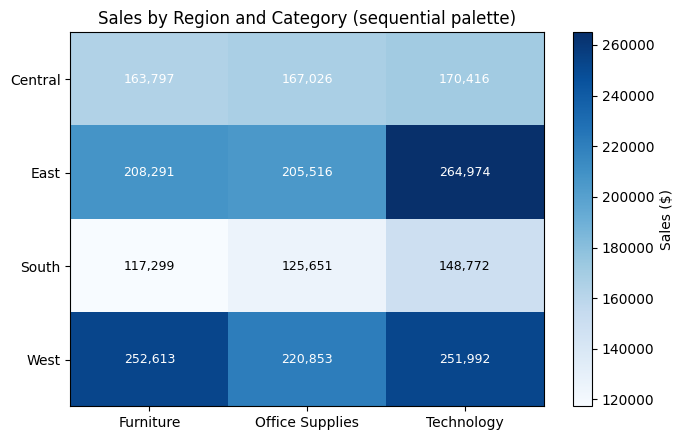

In [28]:
pivot_region_cat = df.pivot_table(index='region', columns='category',
                                   values='sales', aggfunc='sum')

fig, ax = plt.subplots(figsize=(7, 4.5))
# light -> dark as magnitude increases
im = ax.imshow(pivot_region_cat.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pivot_region_cat.columns)))
ax.set_xticklabels(pivot_region_cat.columns)
ax.set_yticks(range(len(pivot_region_cat.index)))
ax.set_yticklabels(pivot_region_cat.index)
ax.set_title('Sales by Region and Category (sequential palette)')
for i in range(pivot_region_cat.shape[0]):
    for j in range(pivot_region_cat.shape[1]):
        val = pivot_region_cat.values[i, j]

        txt_color = 'white' if val > pivot_region_cat.values.max() * 0.6 else 'black'
        ax.text(j, i, f"{val:,.0f}", ha='center', va='center', color=txt_color, fontsize=9)

fig.colorbar(im, ax=ax, label='Sales ($)')
plt.tight_layout()
plt.show()


### 3c. Monthly profit — diverging palette (data crosses zero)

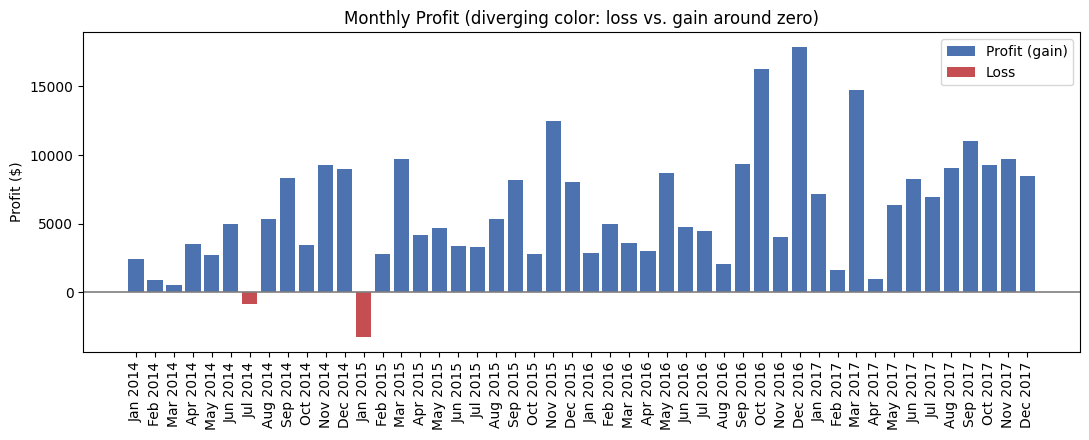

In [29]:
monthly_profit = df.groupby('order_month')['profit'].sum().sort_index()
labels = monthly_profit.index.strftime('%b %Y')

# Diverging palette: two hues meeting at neutral gray at the zero midpoint
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in monthly_profit.values]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(labels, monthly_profit.values, color=colors)
ax.axhline(0, color='#7f7f7f', linewidth=1.2)
ax.set_title('Monthly Profit (diverging color: loss vs. gain around zero)')
ax.set_ylabel('Profit ($)')
ax.tick_params(axis='x', rotation=90)

legend_elems = [Patch(facecolor='#4C72B0', label='Profit (gain)'),
                Patch(facecolor='#C44E52', label='Loss')]
ax.legend(handles=legend_elems)
plt.tight_layout()
plt.show()


## Task 4 — Accessibility: WCAG Contrast & Colorblindness Simulation

### 4a. WCAG contrast ratio function, tested against Task 3's colors

In [30]:
def relative_luminance(rgb):
    """WCAG relative luminance for an (r,g,b) tuple in 0-255 range."""
    def chan(c):
        c = c / 255.0
        return c / 12.92 if c <= 0.03928 else ((c + 0.055) / 1.055) ** 2.4
    r, g, b = rgb
    return 0.2126 * chan(r) + 0.7152 * chan(g) + 0.0722 * chan(b)

def contrast_ratio(rgb1, rgb2):
    """WCAG contrast ratio between two RGB colors (each 0-255 tuple)."""
    l1 = relative_luminance(rgb1)
    l2 = relative_luminance(rgb2)
    lighter, darker = max(l1, l2), min(l1, l2)
    return (lighter + 0.05) / (darker + 0.05)

def hex_to_rgb(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) for i in (0, 2, 4))

# Colors used across Task 3, tested against a white chart background (255,255,255)
white = (255, 255, 255)
task3_colors = {
    'categorical: blue':   '#4C72B0',
    'categorical: orange': '#DD8452',
    'categorical: green':  '#55A868',
    'categorical: red':    '#C44E52',
    'sequential: light blue (low)': '#deebf7',
    'sequential: dark blue (high)': '#08306b',
    'diverging: loss red':  '#C44E52',
    'diverging: gain blue': '#4C72B0',
}

print(f"{'Color':32s} {'Contrast vs white':>18s}   AA (4.5:1) text?")
for name, hexcode in task3_colors.items():
    ratio = contrast_ratio(hex_to_rgb(hexcode), white)
    verdict = 'PASS' if ratio >= 4.5 else 'FAIL'
    print(f"{name:32s} {ratio:15.2f}:1   {verdict}")


Color                             Contrast vs white   AA (4.5:1) text?
categorical: blue                           4.84:1   PASS
categorical: orange                         2.80:1   FAIL
categorical: green                          2.92:1   FAIL
categorical: red                            4.61:1   PASS
sequential: light blue (low)                1.21:1   FAIL
sequential: dark blue (high)               12.76:1   PASS
diverging: loss red                         4.61:1   PASS
diverging: gain blue                        4.84:1   PASS


**(a) Flagged failures:** the bright categorical/diverging fill colors
(blue, orange, green, red) and the pale end of the sequential blue ramp all
fall **below 4.5:1 against a white background** — they are fine as *fill*
colors for bars/cells (large-area color-fill isn't governed by the 4.5:1 text
threshold), but none of them would be safe choices for *text* rendered
directly on white at normal size. Only the darkest end of the sequential
ramp clears AA on its own; any text or thin gridlines drawn in the lighter
palette colors would need a darker outline, a bold weight, or a larger size
to stay compliant, and value labels are safer rendered in solid black/white
as already done in the Task 3(b) heatmap.

### 4b. Colorblind-safe encoding of profit by sub-category

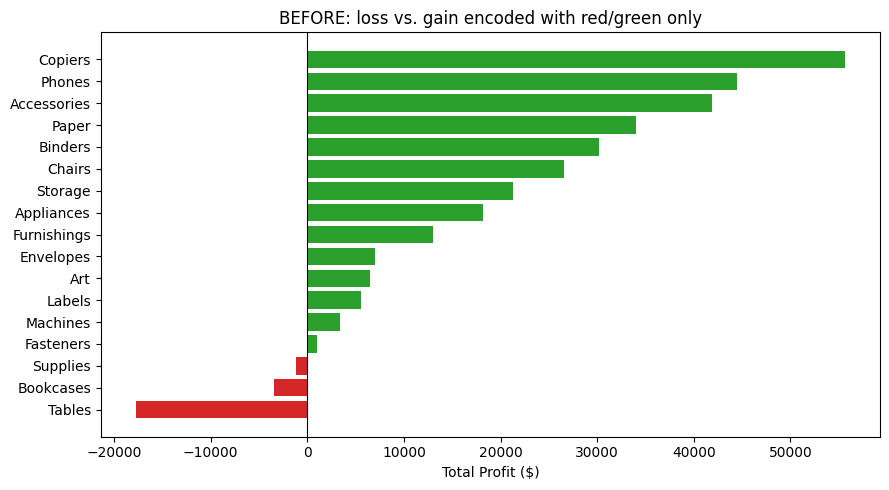

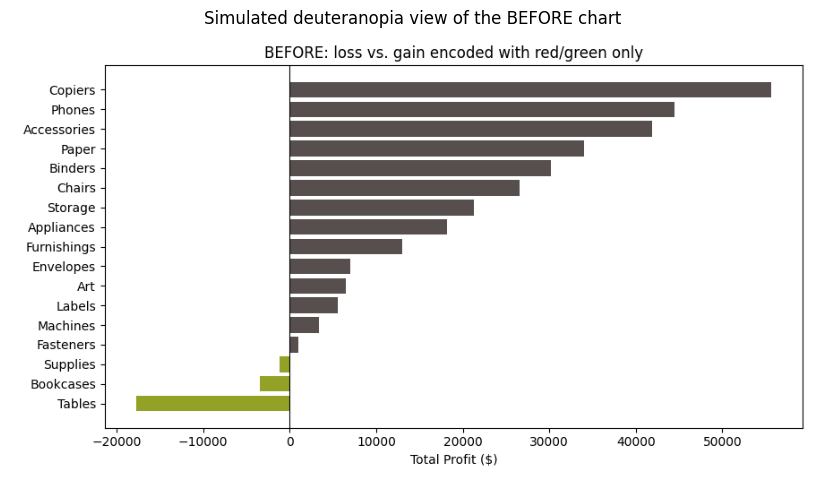

In [31]:
profit_by_subcat = df.groupby('sub_category')['profit'].sum().sort_values()

def simulate_deuteranopia(rgb_array):
    """Approximate deuteranopia (red-green colorblindness) simulation.
    Applies a standard linear approximation matrix to an (H,W,3) uint8 image."""
    M = np.array([[0.625, 0.375, 0.0],
                  [0.700, 0.300, 0.0],
                  [0.000, 0.300, 0.7]])
    flat = rgb_array.reshape(-1, 3).astype(float)
    sim = flat @ M.T
    sim = np.clip(sim, 0, 255).astype(np.uint8)
    return sim.reshape(rgb_array.shape)

def fig_to_rgb_array(fig):
    fig.canvas.draw()
    buf = np.asarray(fig.canvas.buffer_rgba())
    return buf[:, :, :3].copy()

# --- BEFORE: red/green only encodes loss vs gain ---
colors_red_green = ['#d62728' if v < 0 else '#2ca02c' for v in profit_by_subcat.values]
fig1, ax1 = plt.subplots(figsize=(9, 5))
ax1.barh(profit_by_subcat.index, profit_by_subcat.values, color=colors_red_green)
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_title('BEFORE: loss vs. gain encoded with red/green only')
ax1.set_xlabel('Total Profit ($)')
plt.tight_layout()
before_arr = fig_to_rgb_array(fig1)
plt.show()

# --- Run through the colorblind simulator ---
sim_arr = simulate_deuteranopia(before_arr)
fig2, ax2 = plt.subplots(figsize=(9, 5))
ax2.imshow(sim_arr)
ax2.axis('off')
ax2.set_title('Simulated deuteranopia view of the BEFORE chart')
plt.tight_layout()
plt.show()


Under the deuteranopia simulation the red (loss) and green (gain) bars
collapse toward the same muddy hue — a red-green colorblind viewer cannot
reliably tell which sub-categories are losing money using color alone. This
is exactly the failure mode the lab manual warns about, so the chart needs a
second, non-color channel.

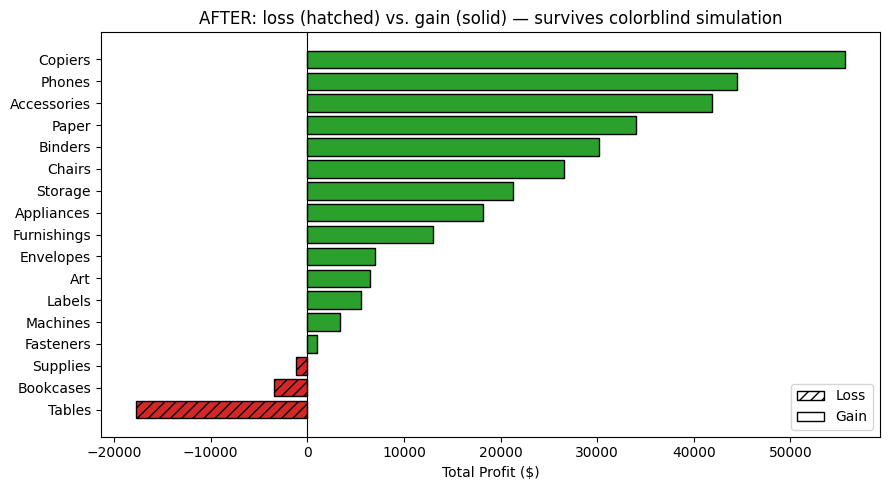

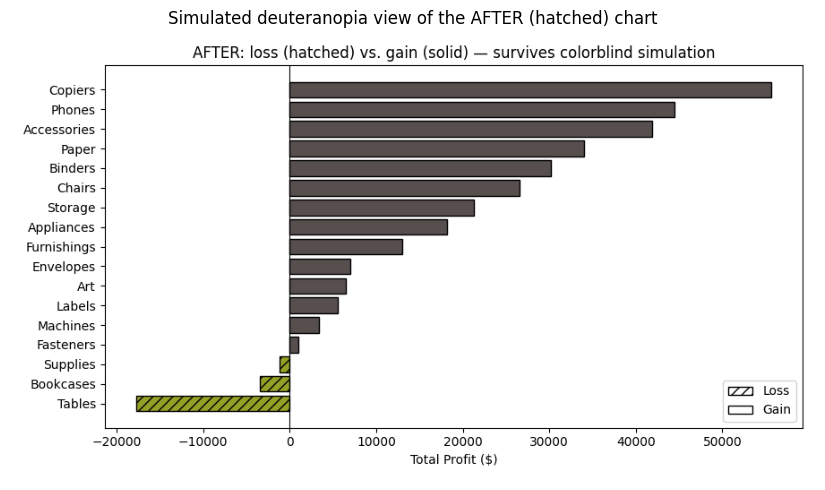

In [32]:
# --- AFTER: fix with hatching (pattern) + direct value labels, not just color ---
fig3, ax3 = plt.subplots(figsize=(9, 5))
bars = ax3.barh(profit_by_subcat.index, profit_by_subcat.values,
                 color=['#d62728' if v < 0 else '#2ca02c' for v in profit_by_subcat.values],
                 edgecolor='black')
for bar, v in zip(bars, profit_by_subcat.values):
    if v < 0:
        bar.set_hatch('///')   # loss = hatched pattern
    # gain bars left solid
ax3.axvline(0, color='black', linewidth=0.8)
ax3.set_title('AFTER: loss (hatched) vs. gain (solid) — survives colorblind simulation')
ax3.set_xlabel('Total Profit ($)')

legend_elems = [Patch(facecolor='white', edgecolor='black', hatch='///', label='Loss'),
                Patch(facecolor='white', edgecolor='black', label='Gain')]
ax3.legend(handles=legend_elems, loc='lower right')
plt.tight_layout()
after_arr = fig_to_rgb_array(fig3)
plt.show()

# Confirm the fix survives simulation too
sim_after = simulate_deuteranopia(after_arr)
fig4, ax4 = plt.subplots(figsize=(9, 5))
ax4.imshow(sim_after)
ax4.axis('off')
ax4.set_title('Simulated deuteranopia view of the AFTER (hatched) chart')
plt.tight_layout()
plt.show()


**Alt text for the fixed chart:** "Horizontal bar chart of total profit by "
"product sub-category, sorted from largest loss to largest gain; loss bars are "
"hatched with diagonal lines and gain bars are solid, so the loss/gain "
"distinction does not depend on color alone."

Even after simulation, the hatching keeps loss bars visually distinct from
gain bars regardless of hue perception, satisfying the "don't rely on color
alone" requirement.

## Task 5 — Reproducing Misleading Visualizations
Three distortion techniques applied to the region-sales and monthly-sales/profit data used earlier.

### 5a. Truncated y-axis on the region sales chart

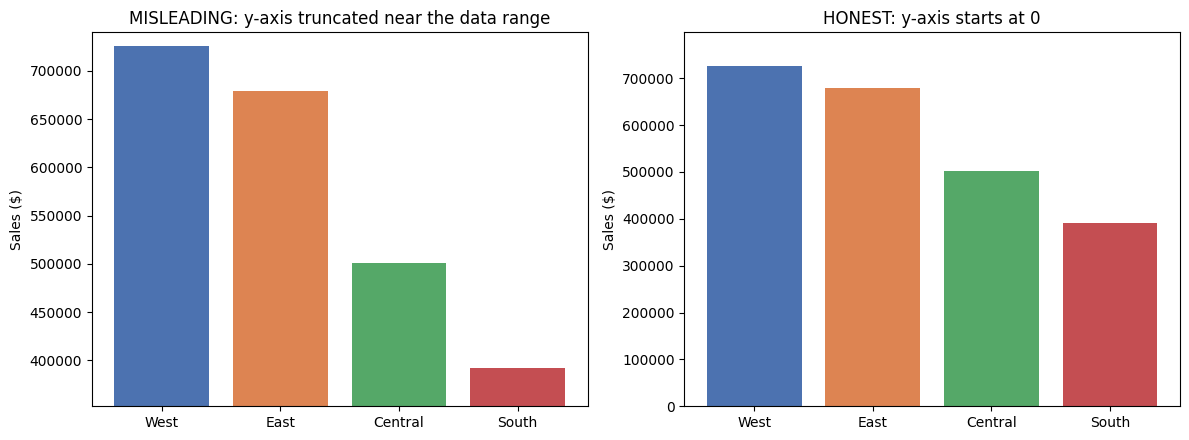

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(region_sales.index, region_sales.values, color=cat_palette[:len(region_sales)])
axes[0].set_ylim(region_sales.min() * 0.9, region_sales.max() * 1.02)
axes[0].set_title('MISLEADING: y-axis truncated near the data range')
axes[0].set_ylabel('Sales ($)')

axes[1].bar(region_sales.index, region_sales.values, color=cat_palette[:len(region_sales)])
axes[1].set_ylim(0, region_sales.max() * 1.1)
axes[1].set_title('HONEST: y-axis starts at 0')
axes[1].set_ylabel('Sales ($)')

plt.tight_layout()
plt.show()


**Distortion mechanism:** truncating the y-axis so it starts near the smallest bar exaggerates the *visual* size difference between regions far beyond their actual proportional difference in sales.

### 5b. Dual-axis chart implying a fake correlation

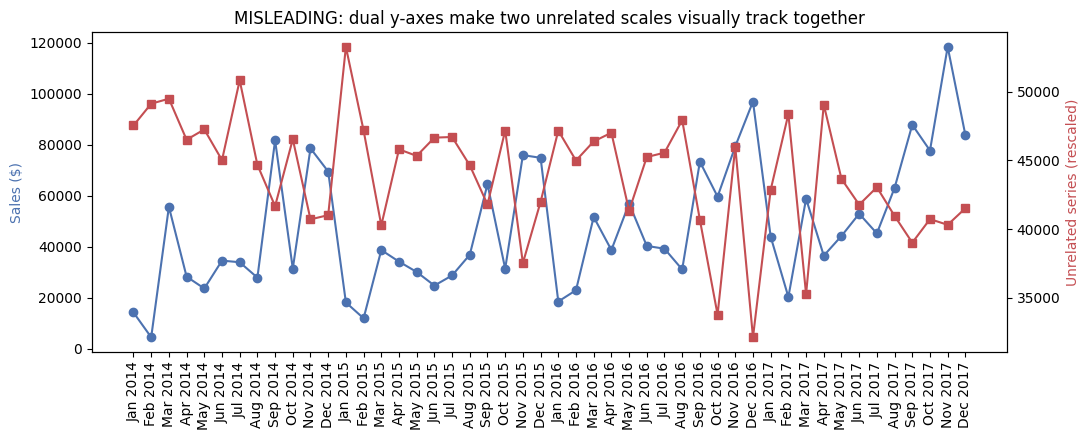

In [34]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax2 = ax1.twinx()

# Two genuinely different-scale, largely unrelated series overlaid to visually
# suggest they move together
ax1.plot(labels, monthly_sales.values, color='#4C72B0', marker='o', label='Sales ($)')
ax2.plot(labels, np.array(monthly_profit.values) * -1 + 50000,
         color='#C44E52', marker='s', label='Unrelated inverted series')

ax1.set_ylabel('Sales ($)', color='#4C72B0')
ax2.set_ylabel('Unrelated series (rescaled)', color='#C44E52')
ax1.set_title('MISLEADING: dual y-axes make two unrelated scales visually track together')
ax1.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()


**Distortion mechanism:** each series has its own independently-scaled axis, so the two lines can be stretched/shifted until they visually appear to move together, implying a correlation that the underlying numbers don't actually support.

### 5c. Cherry-picked date window hiding the surrounding trend

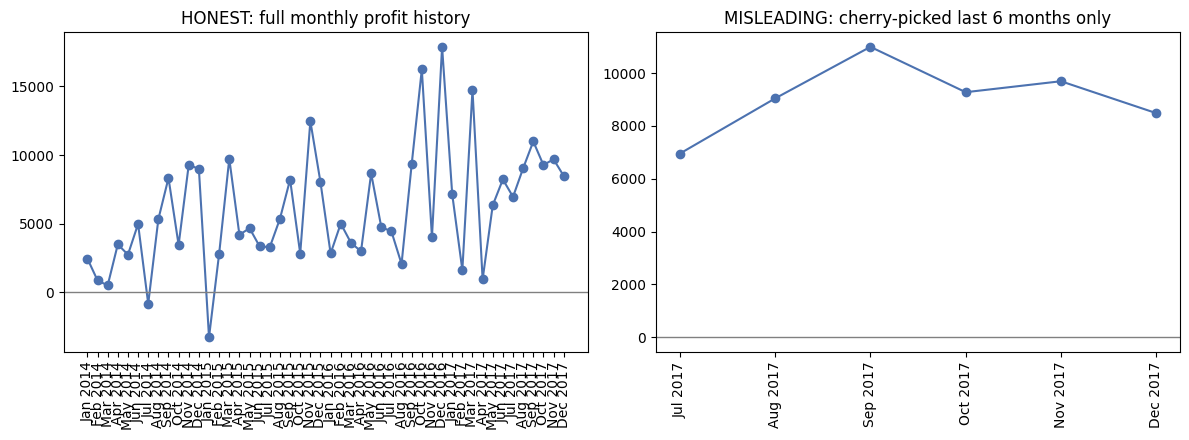

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Full trend
axes[0].plot(labels, monthly_profit.values, color='#4C72B0', marker='o')
axes[0].axhline(0, color='gray', linewidth=1)
axes[0].set_title('HONEST: full monthly profit history')
axes[0].tick_params(axis='x', rotation=90)

# Cherry-picked window: only the months showing a clean upward run
window = monthly_profit.iloc[-6:]
window_labels = labels[-6:]
axes[1].plot(window_labels, window.values, color='#4C72B0', marker='o')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_title('MISLEADING: cherry-picked last 6 months only')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


**Distortion mechanism:** restricting the visible range to a favorable sub-window hides the volatility and dips present in the full history, making a short recent uptrend look like the whole story.

## Task 6 — Analytical Question

### 6a. Honest chart

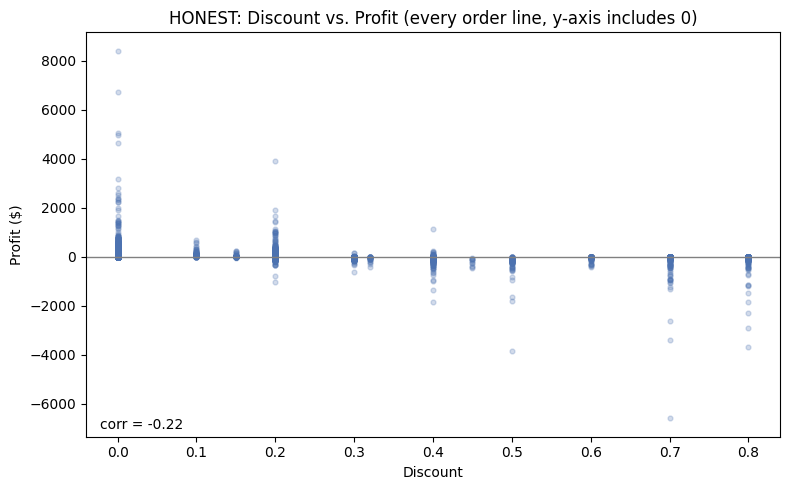

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['discount'], df['profit'], alpha=0.25, s=12, color='#4C72B0')
ax.axhline(0, color='gray', linewidth=1)
ax.set_title('HONEST: Discount vs. Profit (every order line, y-axis includes 0)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($)')

# annotate the underlying correlation for reference
corr = df['discount'].corr(df['profit'])
ax.text(0.02, 0.02, f'corr = {corr:.2f}', transform=ax.transAxes)
plt.tight_layout()
plt.show()


### 6b. Deliberately misleading version of the same question

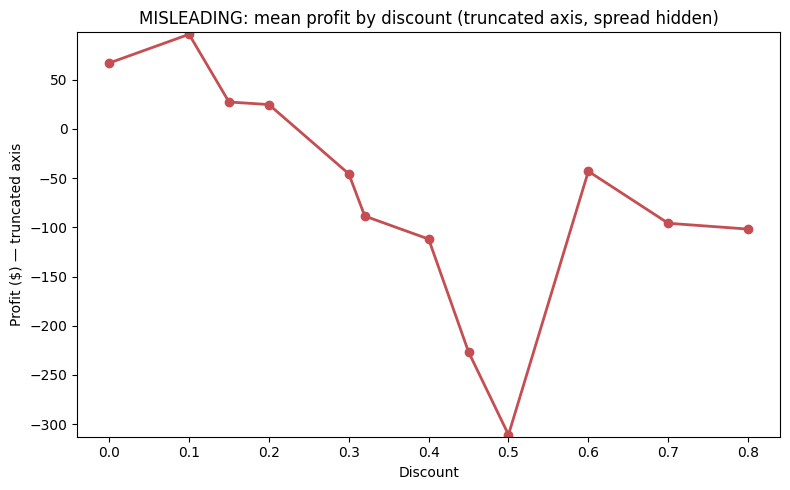

In [38]:
# Misleading version: aggregate away the spread, truncate the y-axis, and
# use a smooth line that implies a clean deterministic decline
disc_mean = df.groupby('discount')['profit'].mean().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(disc_mean.index, disc_mean.values, color='#C44E52', marker='o', linewidth=2)
ax.set_ylim(disc_mean.min() - 2, disc_mean.max() + 2)   # truncated axis, no zero line shown
ax.set_title('MISLEADING: mean profit by discount (truncated axis, spread hidden)')
ax.set_xlabel('Discount')
ax.set_ylabel('Profit ($) — truncated axis')
plt.tight_layout()
plt.show()


Chart type choice

A scatter plot is best because it shows the relationship between discount and profit.

It also shows the spread, trends, and outliers in the data.

Color choice

Blue is used because there is only one data series, so one color is enough.

Low opacity makes overlapping points easier to see.

Accessibility check

The chart does not depend on color alone, so it is easy for colorblind users to understand.

The zero line also clearly shows which points represent profit or loss.